# Joint-RL vs Joint-RL Stag Hunt Analysis

This notebook follows the structure of the adults unified notebook: Python for data preparation and plotting, then `rpy2`/`%%R` for mixed-effects models.

All descriptive and inferential analyses are split by `signalingPathType`, with one subplot or one model section each for:
- `equal-optimal`
- `costly-suboptimal`

Within each path type, the trial-level measures are organized by `utilityStructure`:
- `favor_hare`
- `tie`
- `favor_stag`

## 1. Imports, Paths, and Plot Style

In [10]:
import os
import warnings
from pathlib import Path

from IPython import get_ipython
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats

warnings.filterwarnings('ignore')

ip = get_ipython()
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')

UTILITY_ORDER = ['favor_hare', 'tie', 'favor_stag']
PATH_TYPE_ORDER = ['equal-optimal', 'costly-suboptimal']
SIGNALING_ORDER = ['non_signaling', 'signaling']
OUTCOME_ORDER = ['both_stag', 'both_rabbit', 'different_big_goals', 'player1_rabbit', 'player2_rabbit', 'nothing']

UTILITY_PALETTE = {
    'favor_hare': '#AA2B46',
    'tie': '#E58760',
    'favor_stag': '#F6DEA4'
}
SIGNALING_PALETTE = {
    'non_signaling': '#C9DEE5',
    'signaling': '#3B5DA3'
}
OUTCOME_PALETTE = {
    'both_stag': '#3B5DA3',
    'both_rabbit': '#E58760',
    'different_big_goals': '#6CB3DA',
    'player1_rabbit': '#F6DEA4',
    'player2_rabbit': '#C9DEE5',
    'nothing': '#B0B0B0'
}

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
    'font.family': 'Arial'
})

candidate_dirs = [
    Path('dataAnalysis/generated/stag_hunt_joint_rl_vs_joint_rl_n30'),
    Path('generated/stag_hunt_joint_rl_vs_joint_rl_n30')
]
OUTPUT_DIR = None
for candidate in candidate_dirs:
    if (candidate / 'trial_level.csv').exists():
        OUTPUT_DIR = candidate
        break

if OUTPUT_DIR is None:
    raise FileNotFoundError(
        'Missing simulation output in any expected directory: ' + ', '.join(str(path) for path in candidate_dirs)
    )

TRIAL_PATH = OUTPUT_DIR / 'trial_level.csv'
RUN_PATH = OUTPUT_DIR / 'run_summary.csv'
SUMMARY_PATH = OUTPUT_DIR / 'analysis_summary.csv'
SIGNAL_COMPARISON_PATH = OUTPUT_DIR / 'signal_comparison_summary.csv'

print(f'Using output directory: {OUTPUT_DIR.resolve()}')


Using output directory: /Users/chengshaozhe/Documents/DukeECClab/code/multiplePlayerGridGame_socketIO/.claude/worktrees/naughty-mirzakhani/dataAnalysis/generated/stag_hunt_joint_rl_vs_joint_rl_n30


## 2. Data Loading and Trial-Level Validation

In [11]:
trial_df = pd.read_csv(TRIAL_PATH)
run_df = pd.read_csv(RUN_PATH)

for col in ['stagHuntSuccess', 'collaborationSucceeded', 'signalerChoseSignalingPath', 'invalidOffGoalAction']:
    trial_df[col] = trial_df[col].astype(bool)

trial_df['signalingPathType'] = pd.Categorical(trial_df['signalingPathType'], categories=PATH_TYPE_ORDER, ordered=True)
trial_df['utilityStructure'] = pd.Categorical(trial_df['utilityStructure'], categories=UTILITY_ORDER, ordered=True)
trial_df['signalingLabel'] = pd.Categorical(
    np.where(trial_df['signalerChoseSignalingPath'], 'signaling', 'non_signaling'),
    categories=SIGNALING_ORDER,
    ordered=True
)
trial_df['outcomeCategory'] = pd.Categorical(trial_df['outcomeCategory'], categories=OUTCOME_ORDER)
trial_df['totalMoves'] = trial_df['player1MoveCount'] + trial_df['player2MoveCount']
trial_df['signalerChoseSignalingPathInt'] = trial_df['signalerChoseSignalingPath'].astype(int)
trial_df['stagHuntSuccessInt'] = trial_df['stagHuntSuccess'].astype(int)

assert len(trial_df) == 30 * 18, f'Expected 540 trial rows, found {len(trial_df)}'
assert len(run_df) == 30, f'Expected 30 run rows, found {len(run_df)}'
assert trial_df['mapId'].nunique() == 18, f"Expected 18 unique maps, found {trial_df['mapId'].nunique()}"
assert (trial_df.groupby('mapId').size() == 30).all(), 'Each map should appear exactly 30 times'
assert set(trial_df['signalingPathType'].dropna().unique()) == set(PATH_TYPE_ORDER), 'Missing path type(s)'
assert set(trial_df['utilityStructure'].dropna().unique()) == set(UTILITY_ORDER), 'Missing utility structure(s)'
assert (~trial_df['invalidOffGoalAction']).all(), 'Found invalid off-goal actions in trial data'
assert np.allclose(trial_df['teamRoundPoints'], trial_df['player1RoundPoints'] + trial_df['player2RoundPoints']), 'teamRoundPoints mismatch'
assert np.allclose(trial_df['utilityDeltaStagMinusHare'], trial_df['stagFinalUtility'] - trial_df['hareFinalUtility']), 'utility delta mismatch'
assert (trial_df.groupby('runId')['teamTotalPoints'].diff().fillna(0) >= 0).all(), 'teamTotalPoints must be monotone within run'

display(trial_df.head())
display(
    trial_df.groupby(['signalingPathType', 'utilityStructure']).size().rename('trialCount').reset_index()
)
print('Trial-level validation complete.')


,runId,trialIndexWithinRun,mapId,seed,agentTypePlayer1,agentTypePlayer2,temperature,experimentType,player1Role,player2Role,...,player2OutcomeReward,teamOutcomeReward,player1StepPenaltyPaid,player2StepPenaltyPaid,initialPointsPerTrial,mapAscii,signalingLabel,totalMoves,signalerChoseSignalingPathInt,stagHuntSuccessInt
0,1,1,1,20261419,joint-rl,joint-rl,3,StagHunt,Non-Signaler,Signaler,...,5,10,3,5,15,####O....\n####.###.\n####.###.\n####.###.\n.....,non_signaling,8,0,0
1,1,2,2,20261420,joint-rl,joint-rl,3,StagHunt,Non-Signaler,Signaler,...,10,20,12,8,15,####O....\n####.###.\n####.###.\n####.#r#.\n.....,signaling,20,1,1
2,1,3,3,20261421,joint-rl,joint-rl,3,StagHunt,Non-Signaler,Signaler,...,5,10,4,3,15,####O....\n####.###.\n###r.###.\n####.###.\n.....,non_signaling,7,0,0
3,1,4,4,20261422,joint-rl,joint-rl,3,StagHunt,Non-Signaler,Signaler,...,10,20,12,8,15,####O....\n####.###.\n####.###.\n####.#r#.\n.....,non_signaling,20,0,1
4,1,5,5,20261423,joint-rl,joint-rl,3,StagHunt,Non-Signaler,Signaler,...,10,20,12,8,15,####O....\n####.###.\n####.###.\n####.#r#.\n.....,non_signaling,20,0,1


,signalingPathType,utilityStructure,trialCount
0,equal-optimal,favor_hare,90
1,equal-optimal,tie,90
2,equal-optimal,favor_stag,90
3,costly-suboptimal,favor_hare,90
4,costly-suboptimal,tie,90
5,costly-suboptimal,favor_stag,90


Trial-level validation complete.


## 3. Descriptive Summaries and Output Tables

In [12]:
def ci95(series):
    values = pd.Series(series).dropna().astype(float)
    if len(values) <= 1:
        return 0.0
    return float(stats.sem(values) * stats.t.ppf(0.975, len(values) - 1))

def save_figure(fig, filename):
    path = OUTPUT_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches='tight')
    display(fig)
    print(f'Saved {path}')
    plt.close(fig)

analysis_summary_df = (
    trial_df.groupby(['signalingPathType', 'utilityStructure'])
    .agg(
        trialCount=('mapId', 'size'),
        signalingRate=('signalerChoseSignalingPathInt', 'mean'),
        stagSuccessRate=('stagHuntSuccessInt', 'mean'),
        meanTeamRoundPoints=('teamRoundPoints', 'mean'),
        meanTeamUtility=('teamUtility', 'mean'),
        meanSteps=('steps', 'mean')
    )
    .reset_index()
)

outcome_summary = (
    trial_df.groupby(['signalingPathType', 'utilityStructure', 'outcomeCategory']).size()
    .rename('count')
    .reset_index()
)
outcome_summary['proportion'] = outcome_summary.groupby(['signalingPathType', 'utilityStructure'])['count'].transform(lambda s: s / s.sum())
outcome_wide = outcome_summary.pivot_table(
    index=['signalingPathType', 'utilityStructure'],
    columns='outcomeCategory',
    values='count',
    fill_value=0
)
outcome_wide.columns = [f'{col}Count' for col in outcome_wide.columns]
analysis_summary_df = analysis_summary_df.merge(outcome_wide.reset_index(), on=['signalingPathType', 'utilityStructure'], how='left')

signal_comparison_df = (
    trial_df.groupby(['signalingPathType', 'utilityStructure', 'signalingLabel'])
    .agg(
        trialCount=('mapId', 'size'),
        stagSuccessRate=('stagHuntSuccessInt', 'mean'),
        meanTeamRoundPoints=('teamRoundPoints', 'mean'),
        meanTeamUtility=('teamUtility', 'mean')
    )
    .reset_index()
)

analysis_summary_df.to_csv(SUMMARY_PATH, index=False)
signal_comparison_df.to_csv(SIGNAL_COMPARISON_PATH, index=False)

display(analysis_summary_df.round(4))
display(signal_comparison_df.round(4))


,signalingPathType,utilityStructure,trialCount,signalingRate,stagSuccessRate,meanTeamRoundPoints,meanTeamUtility,meanSteps,both_stagCount,both_rabbitCount,different_big_goalsCount,player1_rabbitCount,player2_rabbitCount,nothingCount
0,equal-optimal,favor_hare,90,0.0000,0.0000,33.6222,3.6222,3.6778,0.0,90.0,0.0,0.0,0.0,0.0
1,equal-optimal,tie,90,0.4889,0.7111,29.8000,-0.2000,10.5111,64.0,26.0,0.0,0.0,0.0,0.0
2,equal-optimal,favor_stag,90,0.5000,1.0000,29.9111,-0.0889,12.0667,90.0,0.0,0.0,0.0,0.0,0.0
3,costly-suboptimal,favor_hare,90,0.0000,0.0000,33.6000,3.6000,3.7111,0.0,90.0,0.0,0.0,0.0,0.0
4,costly-suboptimal,tie,90,0.0111,0.4667,29.5778,-0.4222,9.2444,42.0,48.0,0.0,0.0,0.0,0.0
5,costly-suboptimal,favor_stag,90,0.0000,1.0000,29.8667,-0.1333,12.1111,90.0,0.0,0.0,0.0,0.0,0.0


,signalingPathType,utilityStructure,signalingLabel,trialCount,stagSuccessRate,meanTeamRoundPoints,meanTeamUtility
0,equal-optimal,favor_hare,non_signaling,90,0.0000,33.6222,3.6222
1,equal-optimal,favor_hare,signaling,0,NaN,NaN,NaN
2,equal-optimal,tie,non_signaling,46,0.4348,29.6522,-0.3478
3,equal-optimal,tie,signaling,44,1.0000,29.9545,-0.0455
4,equal-optimal,favor_stag,non_signaling,45,1.0000,29.8222,-0.1778
5,equal-optimal,favor_stag,signaling,45,1.0000,30.0000,0.0000
6,costly-suboptimal,favor_hare,non_signaling,90,0.0000,33.6000,3.6000
7,costly-suboptimal,favor_hare,signaling,0,NaN,NaN,NaN
8,costly-suboptimal,tie,non_signaling,89,0.4607,29.5955,-0.4045
9,costly-suboptimal,tie,signaling,1,1.0000,28.0000,-2.0000


## 4. Descriptive Plots

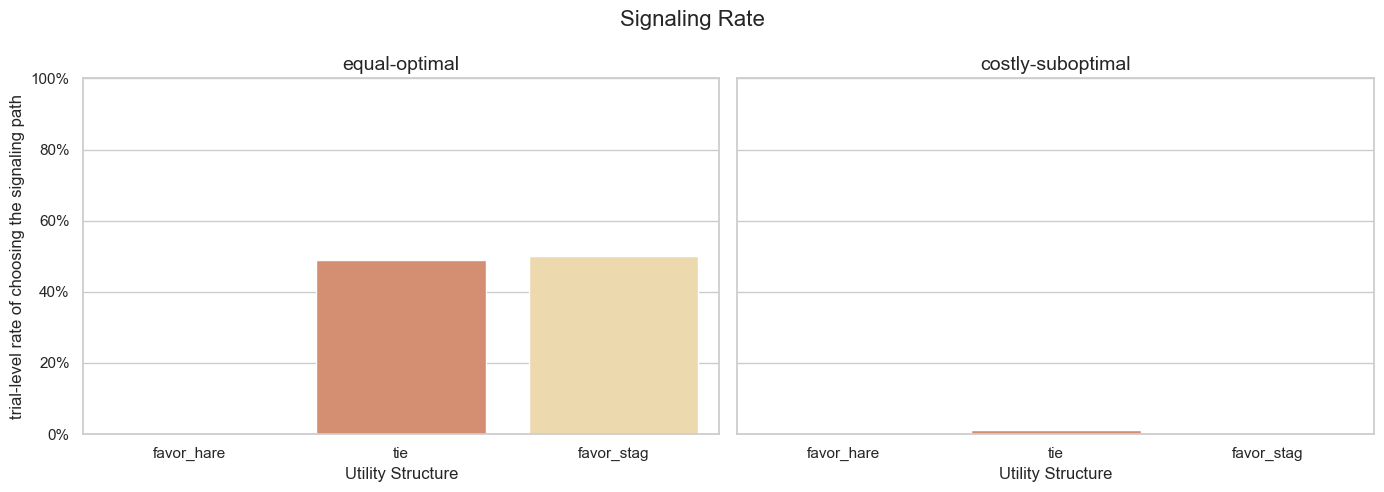

Saved generated/stag_hunt_joint_rl_vs_joint_rl_n30/signaling_rate_by_path_and_utility.png


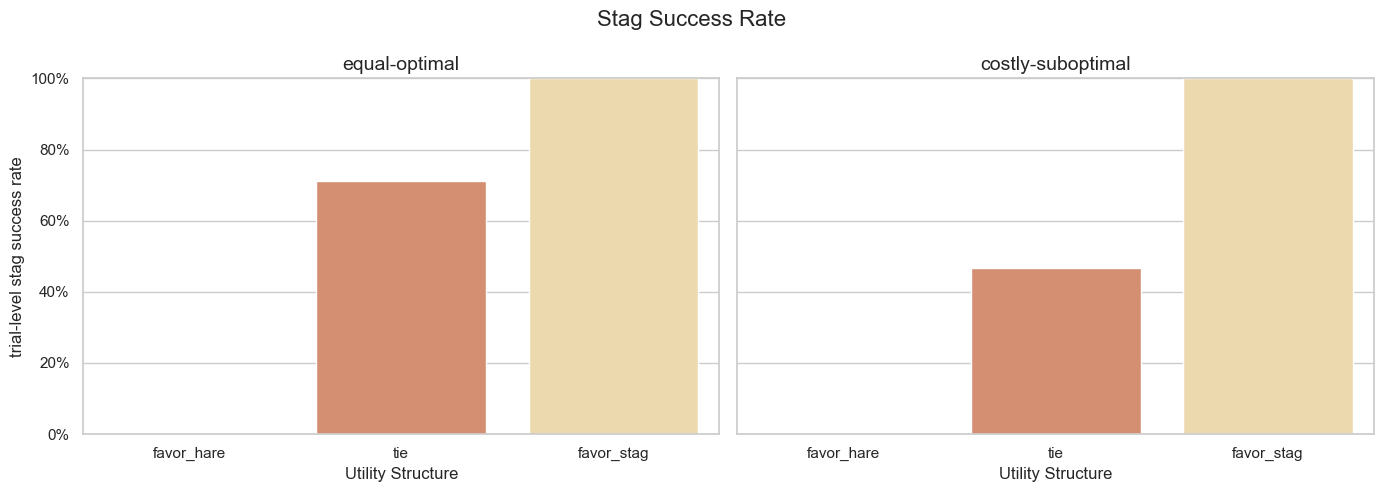

Saved generated/stag_hunt_joint_rl_vs_joint_rl_n30/stag_success_rate_by_path_and_utility.png


In [13]:
rate_metrics = [
    ('signalingRate', 'Signaling Rate', 'trial-level rate of choosing the signaling path', 'signaling_rate_by_path_and_utility.png'),
    ('stagSuccessRate', 'Stag Success Rate', 'trial-level stag success rate', 'stag_success_rate_by_path_and_utility.png')
]

for metric, title, y_label, filename in rate_metrics:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, path_type in zip(axes, PATH_TYPE_ORDER):
        sub = analysis_summary_df[analysis_summary_df['signalingPathType'] == path_type].copy()
        sns.barplot(
            data=sub,
            x='utilityStructure',
            y=metric,
            order=UTILITY_ORDER,
            palette=UTILITY_PALETTE,
            ax=ax
        )
        ax.set_ylim(0, 1)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
        ax.set_title(path_type)
        ax.set_xlabel('Utility Structure')
        ax.set_ylabel(y_label if ax is axes[0] else '')
    fig.suptitle(title)
    save_figure(fig, filename)


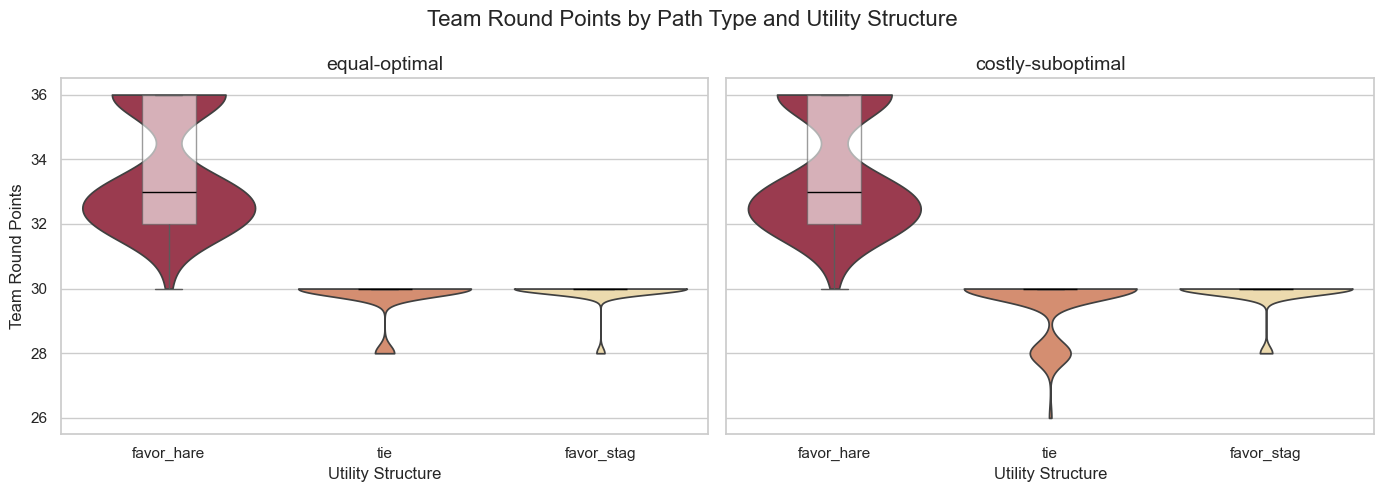

Saved generated/stag_hunt_joint_rl_vs_joint_rl_n30/team_round_points_by_path_and_utility.png


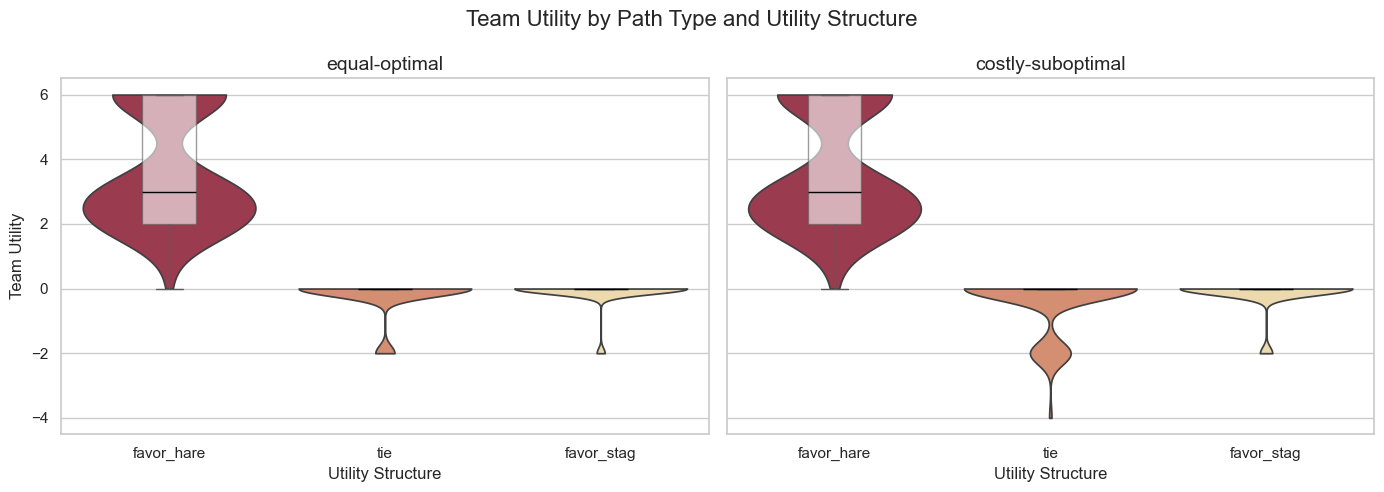

Saved generated/stag_hunt_joint_rl_vs_joint_rl_n30/team_utility_by_path_and_utility.png


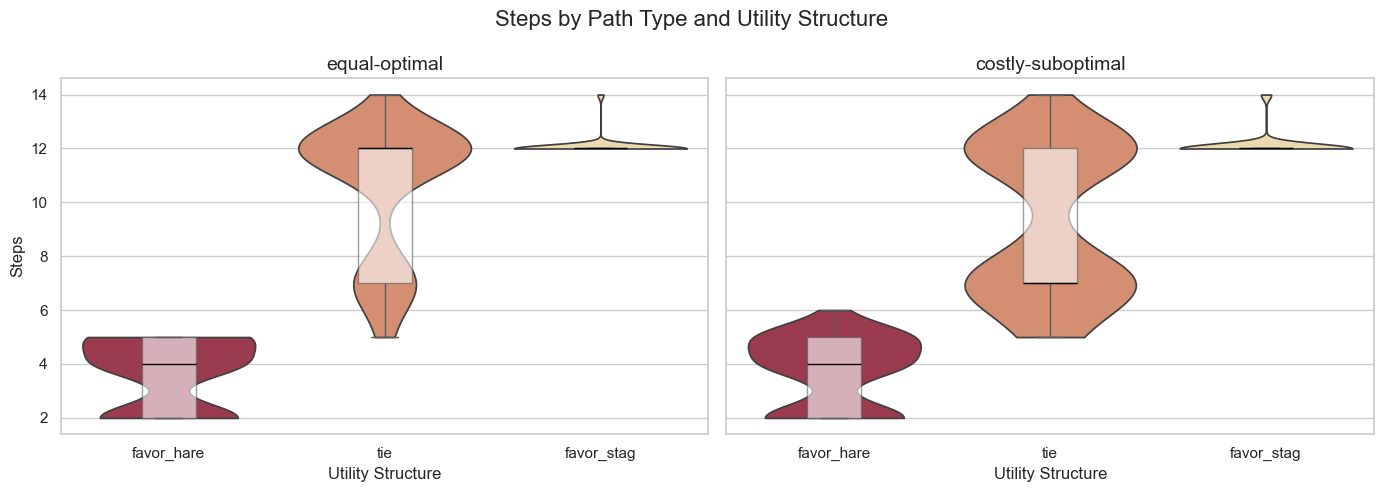

Saved generated/stag_hunt_joint_rl_vs_joint_rl_n30/steps_by_path_and_utility.png


In [14]:
distribution_specs = [
    ('teamRoundPoints', 'Team Round Points', 'team_round_points_by_path_and_utility.png'),
    ('teamUtility', 'Team Utility', 'team_utility_by_path_and_utility.png'),
    ('steps', 'Steps', 'steps_by_path_and_utility.png')
]

for metric, title, filename in distribution_specs:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, path_type in zip(axes, PATH_TYPE_ORDER):
        sub = trial_df[trial_df['signalingPathType'] == path_type].copy()
        sns.violinplot(
            data=sub,
            x='utilityStructure',
            y=metric,
            order=UTILITY_ORDER,
            palette=UTILITY_PALETTE,
            inner=None,
            cut=0,
            ax=ax
        )
        sns.boxplot(
            data=sub,
            x='utilityStructure',
            y=metric,
            order=UTILITY_ORDER,
            showcaps=True,
            boxprops={'facecolor': 'white', 'alpha': 0.6},
            whiskerprops={'linewidth': 1},
            medianprops={'color': 'black'},
            showfliers=False,
            width=0.25,
            ax=ax
        )
        ax.set_title(path_type)
        ax.set_xlabel('Utility Structure')
        ax.set_ylabel(title if ax is axes[0] else '')
    fig.suptitle(f'{title} by Path Type and Utility Structure')
    save_figure(fig, filename)


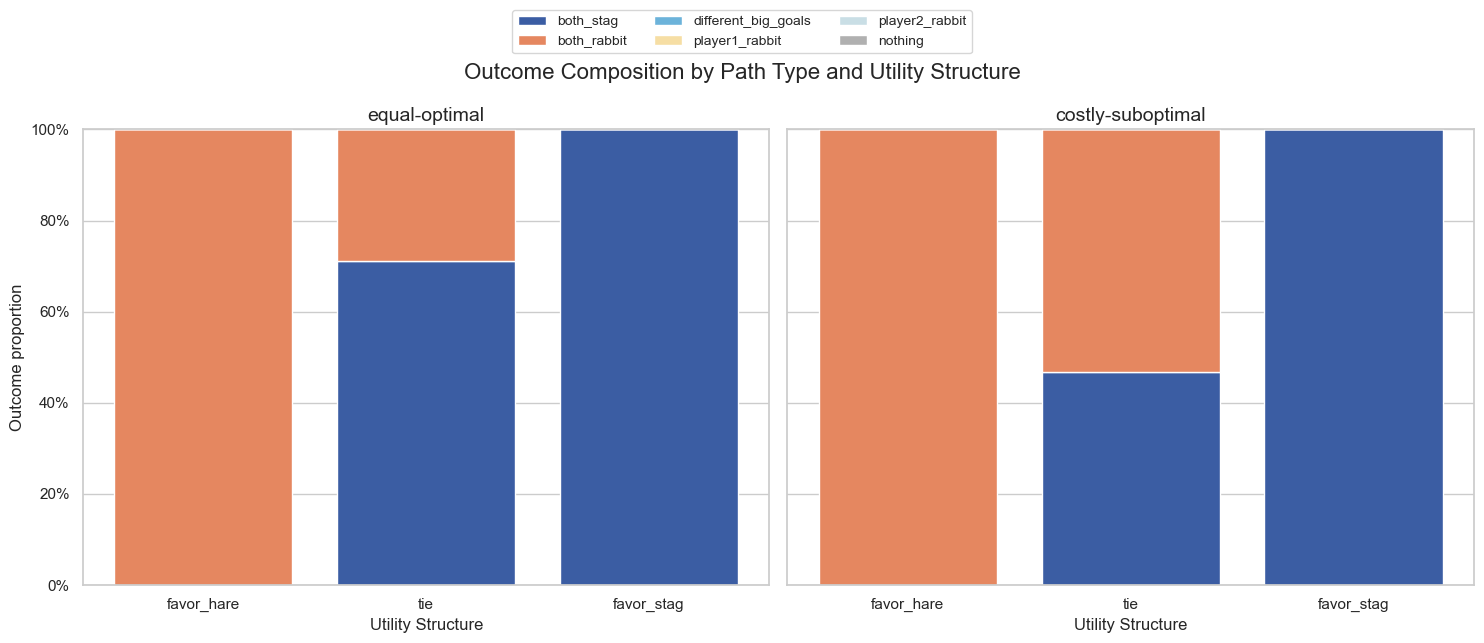

Saved generated/stag_hunt_joint_rl_vs_joint_rl_n30/outcome_composition_by_path_and_utility.png


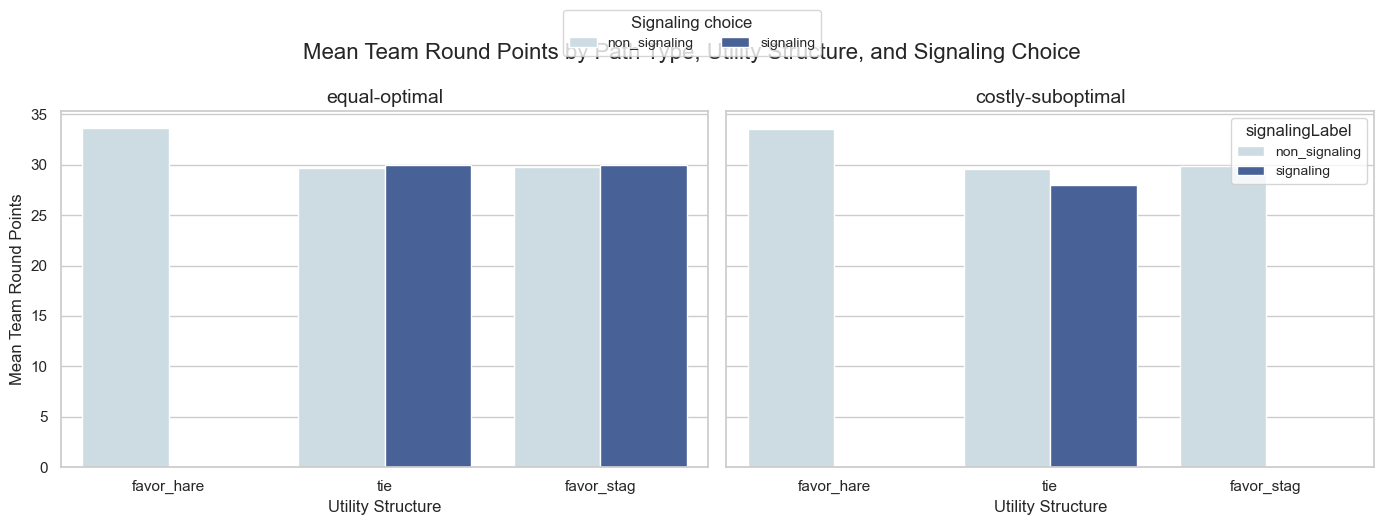

Saved generated/stag_hunt_joint_rl_vs_joint_rl_n30/team_points_signaling_vs_non_signaling_by_path_and_utility.png


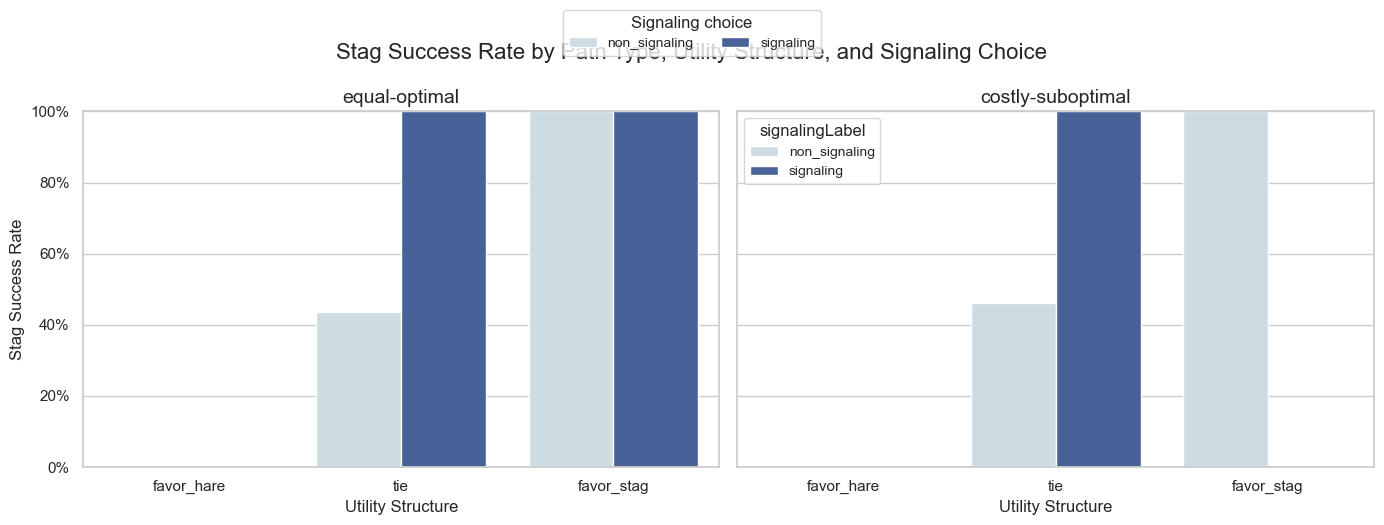

Saved generated/stag_hunt_joint_rl_vs_joint_rl_n30/stag_success_signaling_vs_non_signaling_by_path_and_utility.png


In [15]:
outcome_plot_df = outcome_summary.copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for ax, path_type in zip(axes, PATH_TYPE_ORDER):
    sub = outcome_plot_df[outcome_plot_df['signalingPathType'] == path_type].copy()
    pivot = sub.pivot_table(index='utilityStructure', columns='outcomeCategory', values='proportion', fill_value=0)
    pivot = pivot.reindex(index=UTILITY_ORDER, columns=OUTCOME_ORDER, fill_value=0)
    bottom = np.zeros(len(pivot))
    x = np.arange(len(pivot.index))
    for outcome in OUTCOME_ORDER:
        values = pivot[outcome].to_numpy()
        ax.bar(x, values, bottom=bottom, color=OUTCOME_PALETTE[outcome], label=outcome)
        bottom = bottom + values
    ax.set_xticks(x)
    ax.set_xticklabels(UTILITY_ORDER)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_title(path_type)
    ax.set_xlabel('Utility Structure')
    ax.set_ylabel('Outcome proportion' if ax is axes[0] else '')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=3)
fig.suptitle('Outcome Composition by Path Type and Utility Structure')
save_figure(fig, 'outcome_composition_by_path_and_utility.png')

comparison_specs = [
    ('meanTeamRoundPoints', 'Mean Team Round Points', 'team_points_signaling_vs_non_signaling_by_path_and_utility.png', False),
    ('stagSuccessRate', 'Stag Success Rate', 'stag_success_signaling_vs_non_signaling_by_path_and_utility.png', True)
]

for metric, title, filename, is_rate in comparison_specs:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, path_type in zip(axes, PATH_TYPE_ORDER):
        sub = signal_comparison_df[signal_comparison_df['signalingPathType'] == path_type].copy()
        sns.barplot(
            data=sub,
            x='utilityStructure',
            y=metric,
            hue='signalingLabel',
            order=UTILITY_ORDER,
            hue_order=SIGNALING_ORDER,
            palette=SIGNALING_PALETTE,
            ax=ax
        )
        ax.set_title(path_type)
        ax.set_xlabel('Utility Structure')
        ax.set_ylabel(title if ax is axes[0] else '')
        if is_rate:
            ax.set_ylim(0, 1)
            ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
        if ax is not axes[1]:
            ax.legend_.remove()
    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.06), ncol=2, title='Signaling choice')
    fig.suptitle(title + ' by Path Type, Utility Structure, and Signaling Choice')
    save_figure(fig, filename)


## 5. Python to R Bridge

In [16]:
# Point rpy2 at the system R, matching the adults notebook pattern.
os.environ['R_HOME'] = '/Library/Frameworks/R.framework/Resources'
os.environ['R_LIBS_USER'] = '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/library'

%load_ext rpy2.ipython

r_analysis_df = trial_df.copy()
r_analysis_df['utilityStructure'] = r_analysis_df['utilityStructure'].astype(str)
r_analysis_df['signalingPathType'] = r_analysis_df['signalingPathType'].astype(str)
r_analysis_df['signalingLabel'] = r_analysis_df['signalingLabel'].astype(str)
print(f'r_analysis_df: {r_analysis_df.shape}')


r_analysis_df: (540, 59)


## 6. R Mixed-Effects Models by `signalingPathType`

In [17]:
%%R -i r_analysis_df
suppressPackageStartupMessages({
  library(lme4)
  library(lmerTest)
  library(dplyr)
  library(readr)
  library(ggplot2)
  library(emmeans)
  library(car)
})

options(readr.show_col_types = FALSE)
options(width = 180)
has_blme <- requireNamespace('blme', quietly = TRUE)

fit_logit_mixed <- function(formula, data) {
  fit_glmer <- function() {
    glmer(
      formula,
      data = data,
      family = binomial(link = 'logit'),
      control = glmerControl(optimizer = 'bobyqa', optCtrl = list(maxfun = 2e5))
    )
  }

  if (has_blme) {
    tryCatch(
      blme::bglmer(
        formula,
        data = data,
        family = binomial(link = 'logit'),
        fixef.prior = normal,
        cov.prior = NULL
      ),
      error = function(e) {
        cat(sprintf('blme::bglmer failed (%s); falling back to glmer\n', conditionMessage(e)))
        fit_glmer()
      }
    )
  } else {
    cat('blme not available; using glmer\n')
    fit_glmer()
  }
}

fit_linear_mixed <- function(formula, data) {
  lmer(
    formula,
    data = data,
    REML = FALSE,
    control = lmerControl(optimizer = 'bobyqa', optCtrl = list(maxfun = 2e5))
  )
}

safe_car_anova <- function(model) {
  tryCatch(
    capture.output(print(car::Anova(model))),
    error = function(e) sprintf('Anova unavailable: %s', conditionMessage(e))
  )
}

safe_emmeans <- function(model, spec, type = 'response') {
  tryCatch(
    as.data.frame(summary(emmeans(model, spec, type = type))),
    error = function(e) {
      cat(sprintf('emmeans unavailable: %s\n', conditionMessage(e)))
      NULL
    }
  )
}

df_trial <- r_analysis_df %>%
  mutate(
    runId = as.factor(runId),
    signalingPathType = factor(signalingPathType, levels = c('equal-optimal', 'costly-suboptimal')),
    utilityStructure = factor(utilityStructure, levels = c('favor_hare', 'tie', 'favor_stag')),
    signalerChoseSignalingPath = as.numeric(signalerChoseSignalingPath),
    stagHuntSuccess = as.numeric(stagHuntSuccess)
  )

for (pt in levels(df_trial$signalingPathType)) {
  cat('\n', strrep('=', 100), '\n', sep = '')
  cat('PATH TYPE:', pt, '\n')
  cat(strrep('=', 100), '\n', sep = '')
  df_sub <- df_trial %>% filter(signalingPathType == pt)
  print(df_sub %>% count(utilityStructure, signalerChoseSignalingPath, name = 'n'))

  cat('\n--- Signaling model ---\n')
  signal_counts <- sort(unique(df_sub$signalerChoseSignalingPath))
  if (length(signal_counts) < 2) {
    cat('Skipping signaling model: no variation in signaling outcome.\n')
  } else {
    model_signal <- fit_logit_mixed(signalerChoseSignalingPath ~ utilityStructure + (1 | runId), df_sub)
    print(summary(model_signal))
    cat(paste(safe_car_anova(model_signal), collapse = '\n'), '\n')
    signal_emmeans <- safe_emmeans(model_signal, ~ utilityStructure, type = 'response')
    if (!is.null(signal_emmeans)) {
      cat('\nEstimated marginal means (signaling model):\n')
      print(signal_emmeans)
    }
  }

  cat('\n--- Stag success model ---\n')
  success_counts <- sort(unique(df_sub$stagHuntSuccess))
  if (length(success_counts) < 2) {
    cat('Skipping success model: no variation in success outcome.\n')
  } else {
    model_success <- fit_logit_mixed(stagHuntSuccess ~ utilityStructure * signalerChoseSignalingPath + (1 | runId), df_sub)
    print(summary(model_success))
    cat(paste(safe_car_anova(model_success), collapse = '\n'), '\n')
    success_emmeans <- safe_emmeans(model_success, ~ utilityStructure + signalerChoseSignalingPath, type = 'response')
    if (!is.null(success_emmeans)) {
      cat('\nEstimated marginal means (success model):\n')
      print(success_emmeans)
    }
  }

  cat('\n--- Team points model ---\n')
  model_points <- fit_linear_mixed(teamRoundPoints ~ utilityStructure * signalerChoseSignalingPath + (1 | runId), df_sub)
  print(summary(model_points))
  cat(paste(safe_car_anova(model_points), collapse = '\n'), '\n')
  points_emmeans <- safe_emmeans(model_points, ~ utilityStructure + signalerChoseSignalingPath, type = 'response')
  if (!is.null(points_emmeans)) {
    cat('\nEstimated marginal means (points model):\n')
    print(points_emmeans)
  }

  cat('\n--- Team utility model ---\n')
  model_utility <- fit_linear_mixed(teamUtility ~ utilityStructure * signalerChoseSignalingPath + (1 | runId), df_sub)
  print(summary(model_utility))
  cat(paste(safe_car_anova(model_utility), collapse = '\n'), '\n')
  utility_emmeans <- safe_emmeans(model_utility, ~ utilityStructure + signalerChoseSignalingPath, type = 'response')
  if (!is.null(utility_emmeans)) {
    cat('\nEstimated marginal means (utility model):\n')
    print(utility_emmeans)
  }
}



PATH TYPE: equal-optimal 
  utilityStructure signalerChoseSignalingPath  n
1       favor_hare                          0 90
2              tie                          0 46
3              tie                          1 44
4       favor_stag                          0 45
5       favor_stag                          1 45

--- Signaling model ---
blme::bglmer failed (object 'theta' not found); falling back to glmer
Generalized linear mixed model fit by maximum likelihood (Laplace Approximation) ['glmerMod']
 Family: binomial  ( logit )
Formula: signalerChoseSignalingPath ~ utilityStructure + (1 | runId)
   Data: data
Control: glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e+05))

      AIC       BIC    logLik -2*log(L)  df.resid 
    257.5     271.9    -124.7     249.5       266 

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.00000 -0.97802 -0.00006  1.00000  1.02247 

Random effects:
 Groups Name        Variance Std.Dev.
 runId  (Intercept) 0        0  

boundary (singular) fit: see help('isSingular')
fixed-effect model matrix is rank deficient so dropping 1 column / coefficient
fixed-effect model matrix is rank deficient so dropping 1 column / coefficient
boundary (singular) fit: see help('isSingular')
fixed-effect model matrix is rank deficient so dropping 1 column / coefficient
boundary (singular) fit: see help('isSingular')
fixed-effect model matrix is rank deficient so dropping 1 column / coefficient
fixed-effect model matrix is rank deficient so dropping 1 column / coefficient
boundary (singular) fit: see help('isSingular')
fixed-effect model matrix is rank deficient so dropping 1 column / coefficient
boundary (singular) fit: see help('isSingular')
fixed-effect model matrix is rank deficient so dropping 2 columns / coefficients
fixed-effect model matrix is rank deficient so dropping 2 columns / coefficients
boundary (singular) fit: see help('isSingular')
fixed-effect model matrix is rank deficient so dropping 2 columns / coeffici

## 7. Conclusions

In [18]:
path_summary = analysis_summary_df[['signalingPathType', 'utilityStructure', 'signalingRate', 'stagSuccessRate', 'meanTeamRoundPoints', 'meanTeamUtility']].copy()

for path_type in PATH_TYPE_ORDER:
    sub = analysis_summary_df[analysis_summary_df['signalingPathType'] == path_type].copy()
    signal_trials = int(trial_df[(trial_df['signalingPathType'] == path_type) & (trial_df['signalerChoseSignalingPath'])].shape[0])
    total_trials = int(trial_df[trial_df['signalingPathType'] == path_type].shape[0])
    pooled_points = trial_df[trial_df['signalingPathType'] == path_type].groupby('signalerChoseSignalingPath')['teamRoundPoints'].mean()
    pooled_success = trial_df[trial_df['signalingPathType'] == path_type].groupby('signalerChoseSignalingPath')['stagHuntSuccessInt'].mean()

    print('\n' + '=' * 90)
    print(f'PATH TYPE: {path_type}')
    print('=' * 90)
    display(sub.round(4))
    print(f'Signaling trials: {signal_trials} / {total_trials}')
    if True in pooled_points.index and False in pooled_points.index:
        print(f'Signaling minus non-signaling team-point difference: {pooled_points[True] - pooled_points[False]:.3f}')
    if True in pooled_success.index and False in pooled_success.index:
        print(f'Signaling minus non-signaling stag-success difference: {pooled_success[True] - pooled_success[False]:.3f}')
    if signal_trials < 5:
        print('Caveat: very few signaling trials in this path type; mixed-effects signaling terms may be unstable.')

print('\n' + '=' * 90)
print('POOLED SUMMARY')
print('=' * 90)
print(f"Overall mean team round points: {trial_df['teamRoundPoints'].mean():.3f}")
print(f"Overall mean team utility: {trial_df['teamUtility'].mean():.3f}")
print(f"Overall signaling rate: {trial_df['signalerChoseSignalingPathInt'].mean():.3f}")
print(f"Overall stag success rate: {trial_df['stagHuntSuccessInt'].mean():.3f}")



PATH TYPE: equal-optimal


,signalingPathType,utilityStructure,trialCount,signalingRate,stagSuccessRate,meanTeamRoundPoints,meanTeamUtility,meanSteps,both_stagCount,both_rabbitCount,different_big_goalsCount,player1_rabbitCount,player2_rabbitCount,nothingCount
0,equal-optimal,favor_hare,90,0.0000,0.0000,33.6222,3.6222,3.6778,0.0,90.0,0.0,0.0,0.0,0.0
1,equal-optimal,tie,90,0.4889,0.7111,29.8000,-0.2000,10.5111,64.0,26.0,0.0,0.0,0.0,0.0
2,equal-optimal,favor_stag,90,0.5000,1.0000,29.9111,-0.0889,12.0667,90.0,0.0,0.0,0.0,0.0,0.0


Signaling trials: 89 / 270
Signaling minus non-signaling team-point difference: -1.691
Signaling minus non-signaling stag-success difference: 0.641

PATH TYPE: costly-suboptimal


,signalingPathType,utilityStructure,trialCount,signalingRate,stagSuccessRate,meanTeamRoundPoints,meanTeamUtility,meanSteps,both_stagCount,both_rabbitCount,different_big_goalsCount,player1_rabbitCount,player2_rabbitCount,nothingCount
3,costly-suboptimal,favor_hare,90,0.0000,0.0000,33.6000,3.6000,3.7111,0.0,90.0,0.0,0.0,0.0,0.0
4,costly-suboptimal,tie,90,0.0111,0.4667,29.5778,-0.4222,9.2444,42.0,48.0,0.0,0.0,0.0,0.0
5,costly-suboptimal,favor_stag,90,0.0000,1.0000,29.8667,-0.1333,12.1111,90.0,0.0,0.0,0.0,0.0,0.0


Signaling trials: 1 / 270
Signaling minus non-signaling team-point difference: -3.026
Signaling minus non-signaling stag-success difference: 0.513
Caveat: very few signaling trials in this path type; mixed-effects signaling terms may be unstable.

POOLED SUMMARY
Overall mean team round points: 31.063
Overall mean team utility: 1.063
Overall signaling rate: 0.167
Overall stag success rate: 0.530
